In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, recall_score
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.preprocessing import StandardScaler


In [3]:
df_Ml = pd.read_csv("../../data/weatherAUS_ForModel.csv") 
df_Ml = df_Ml.drop("SeasonName", axis=1)  


print("Nombre total de NaN :", df_Ml.isna().sum().sum())
print("Nombre total de NaN après :", df_Ml.isna().sum().sum())

Nombre total de NaN : 0
Nombre total de NaN après : 0


In [4]:
X = df_Ml.drop(columns=["RainTomorrow", "Date"], errors="ignore")
y = df_Ml["RainTomorrow"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # fit sur le train
X_test = scaler.transform(X_test)

In [6]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    solver="lbfgs"
)
clf = Pipeline(steps=[
    ("classifier", model)
])

clf_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("classifier",model)
])

In [7]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]
threshold = 0.35  # plus sensible à la pluie
y_pred_custom = (y_proba >= threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_custom)
f1 = f1_score(y_test, y_pred_custom)
recall = recall_score(y_test,y_pred_custom)



print(classification_report(y_test, y_pred_custom))
print(f"Accuracy : {accuracy:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"Recall : {recall:.4f}")
print("ROC-AUC :", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.94      0.66      0.78     21757
           1       0.42      0.86      0.57      6262

    accuracy                           0.71     28019
   macro avg       0.68      0.76      0.67     28019
weighted avg       0.83      0.71      0.73     28019

Accuracy : 0.7084
F1-score : 0.5691
Recall : 0.8617
ROC-AUC : 0.8596363961292677


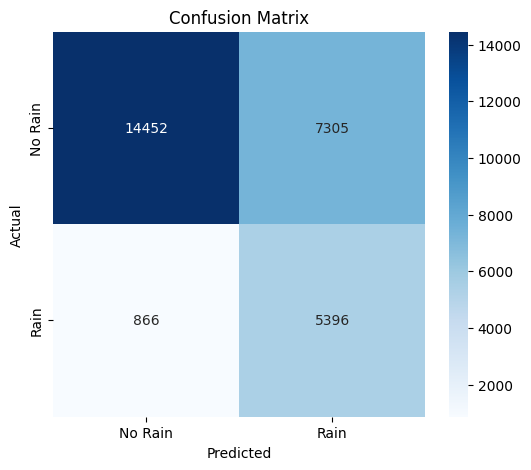

In [8]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [10]:
clf_smote.fit(X_train, y_train)

y_pred = clf_smote.predict(X_test)
y_proba = clf_smote.predict_proba(X_test)[:, 1]
threshold = 0.45  # plus sensible à la pluie
y_pred_custom = (y_proba >= threshold).astype(int)
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred_custom))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred_custom))
print("ROC-AUC :", roc_auc_score(y_test, y_proba))

Matrice de confusion :
[[16587  5170]
 [ 1312  4950]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     21757
           1       0.49      0.79      0.60      6262

    accuracy                           0.77     28019
   macro avg       0.71      0.78      0.72     28019
weighted avg       0.83      0.77      0.78     28019

ROC-AUC : 0.8595108110816717


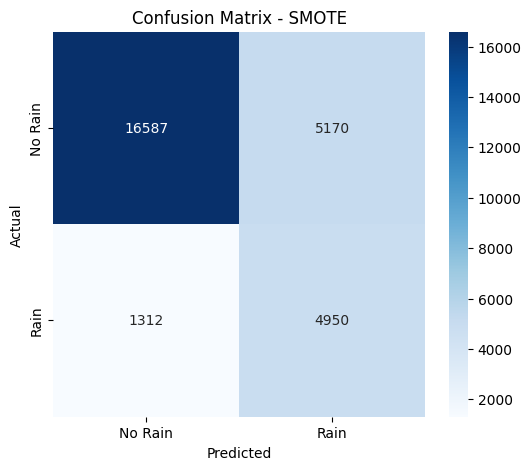

In [12]:
cm = confusion_matrix(y_test, y_pred_custom)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SMOTE")

plt.show()

Pondération des classes 


================ Logistic Regression (class_weight) ================

Ratio: 3.4744680001596997
----------- Rapport de classification -----------
              precision    recall  f1-score   support

           0       0.93      0.76      0.84     21757
           1       0.49      0.79      0.60      6262

    accuracy                           0.77     28019
   macro avg       0.71      0.78      0.72     28019
weighted avg       0.83      0.77      0.78     28019

Accuracy : 0.7683714622220637
F1-score : 0.6033007334963325
Recall : 0.7880868732034494
ROC-AUC : 0.8596368218412935


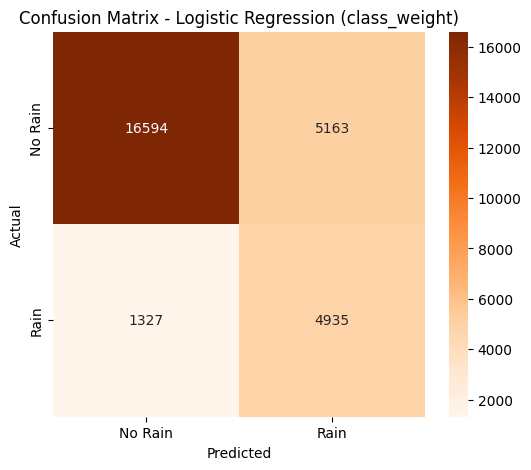

In [13]:
print("\n================ Logistic Regression (class_weight) ================\n")

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

print("Ratio:", ratio)

# Modèle avec pondération
model_lr = LogisticRegression(
    class_weight={0:1, 1:ratio},
    max_iter=1000,
    solver="lbfgs"
)

# Entraînement
model_lr.fit(X_train, y_train)

# Prédictions
y_proba_lr = model_lr.predict_proba(X_test)[:,1]


threshold = 0.45
y_pred_lr = (y_proba_lr >= threshold).astype(int)

# Métriques
print("----------- Rapport de classification -----------")
print(classification_report(y_test, y_pred_lr))

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("F1-score :", f1_score(y_test, y_pred_lr))
print("Recall :", recall_score(y_test, y_pred_lr))
print("ROC-AUC :", roc_auc_score(y_test, y_proba_lr))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression (class_weight)")
plt.show()

In [15]:
print("\n================ COMPARAISON DES MODELES ================\n")

results = []


#Logistic NORMAL

model_normal = LogisticRegression(max_iter=1000, solver="lbfgs")
model_normal.fit(X_train, y_train)

y_proba = model_normal.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

results.append({
    "Model": "Logistic Normal",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
})



# Logistic + SMOTE

model_smote = ImbPipeline(steps=[
    ("smote", SMOTE(random_state=42)),
    ("classifier", LogisticRegression(max_iter=1000))
])

model_smote.fit(X_train, y_train)

y_proba = model_smote.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.45).astype(int)

results.append({
    "Model": "Logistic + SMOTE",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
})



# Logistic + class_weight

neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

model_weight = LogisticRegression(
    class_weight={0:1, 1:ratio},
    max_iter=1000
)

model_weight.fit(X_train, y_train)

y_proba = model_weight.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.40).astype(int)

results.append({
    "Model": "Logistic + class_weight",
    "Accuracy": accuracy_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
})


df_results = pd.DataFrame(results)
print(df_results)


================ COMPARAISON DES MODELES ================

                     Model  Accuracy        F1    Recall   ROC-AUC
0          Logistic Normal  0.842857  0.573642  0.473012  0.859020
1         Logistic + SMOTE  0.768657  0.604322  0.790482  0.859511
2  Logistic + class_weight  0.741176  0.587345  0.824178  0.859637
